In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.signal import find_peaks
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import t
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
from scipy.optimize import minimize

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    #"figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "figure.figsize": (11.6, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

In [3]:
file_path = "csv-files/zro2_white&green_ 50_days.csv"
data_50 = pd.read_csv(file_path, header=None)
file_path2 = "csv-files/new_data.csv"
data_30 = pd.read_csv(file_path2, header=None)

spectrum_50 = data_50[0].values
spectrum_30 = data_30[0].values


t_50 = 4279386 # 50 days exposure
t_30 = 2827661 # 50 days exposure

t_tot = t_50 + t_30



In [4]:
a_50 = 0.357304
b_50 = -0.295444
c_50  = 1.352297E-009
E_kev_50 =  np.arange(len(spectrum_50)) * a_50 + b_50 + c_50 * np.arange(len(spectrum_50))**2
mask = (E_kev_50>=0) & (E_kev_50 <= 3000)
E_kev_50 = E_kev_50[mask]
spectrum_50 = spectrum_50[mask]
spectrum_50_norm = spectrum_50/t_50

In [5]:
b_30 = 2.78
a_30 = 0.4142675
c_30  = 8.4771*1e-7
E_kev_30 =  np.arange(len(spectrum_30)) * a_30 + b_30 + c_30 * np.arange(len(spectrum_30))**2
mask = (E_kev_30>=0) & (E_kev_30 <= 3000)
E_kev_30 = E_kev_30[mask]
spectrum_30 = spectrum_30[mask]
spectrum_30_norm = spectrum_30/t_30

In [9]:
bins_common = np.arange(0,3000,1.26)
bins_common = np.arange(0,3000,0.36)

N50, bin_edge50 = np.histogram(E_kev_50, bins = bins_common, weights = spectrum_50  )

N30, bin_edge30 = np.histogram(E_kev_30, bins = bins_common, weights = spectrum_30)

E_tot = (bin_edge50[1:] + bin_edge50[:-1])/2

Ntot = N50 + N30

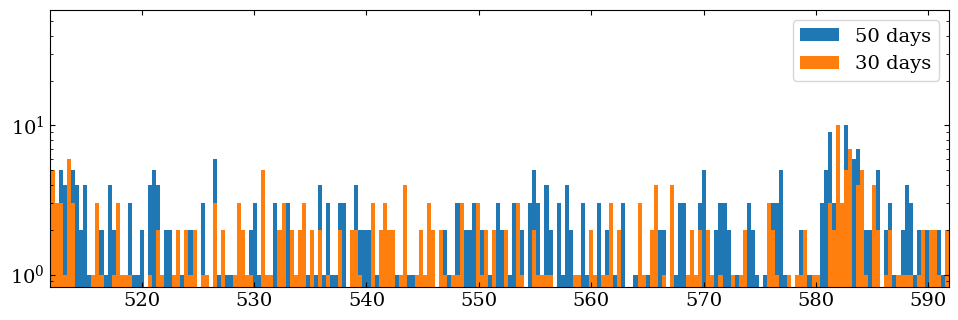

In [10]:
_ = plt.hist(E_kev_50, bins_common, weights=spectrum_50, label="50 days")
_ = plt.hist(E_kev_30, bins_common, weights=spectrum_30, label = "30 days")
plt.legend(loc = "upper right")
plt.xlim([551.8-40, 551.8+40])
plt.yscale('log')

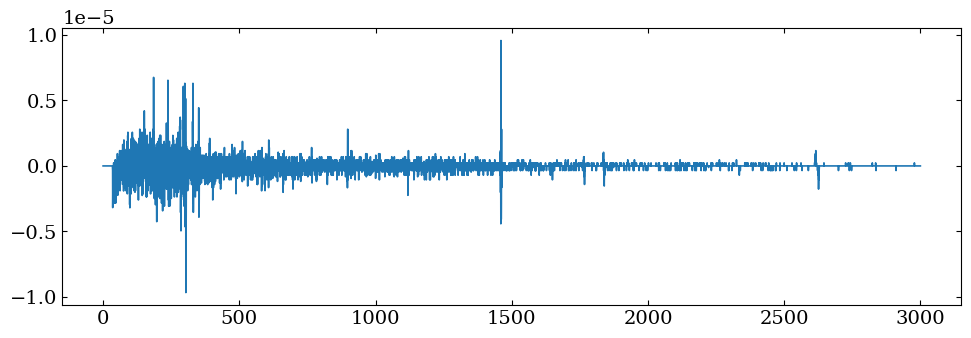

In [11]:
plt.plot(E_tot , (N50/t_50 - N30/t_30))

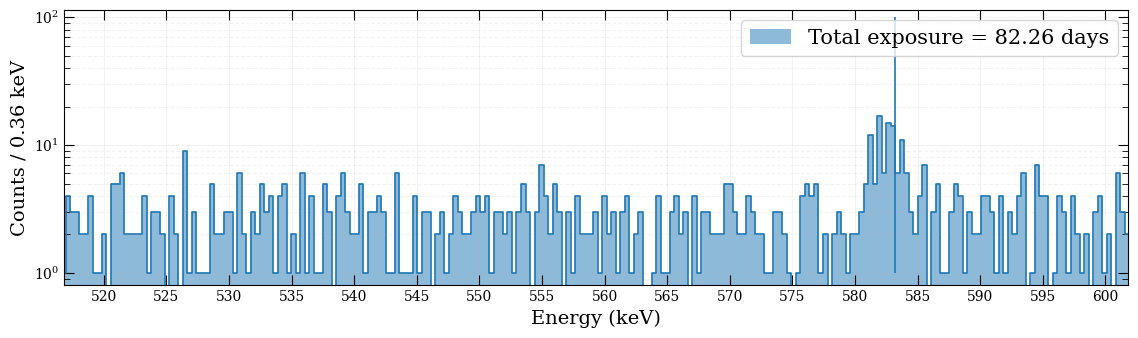

In [20]:
plt.figure()
ax = plt.gca()


dx_major = 5
dx_minor = 100

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
#ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)

# Bin width

bins_common = np.arange(0,3000,1.26)

plt.step(
    E_tot,
    Ntot,
    where='mid',
        
)

plt.fill_between(
    E_tot,
    Ntot,
    step='mid',
    alpha=0.5,
    label = f"Total exposure = {(t_50 + t_30)/(24*60*60) :.2f} days"
)



db = (E_tot[1]-E_tot[0])

plt.xlim([551.8-35, 551.8+50])
plt.xlabel('Energy (keV)')
plt.ylabel(rf'Counts / {db:.2f} keV')
plt.yscale('log')
plt.grid(alpha=0.15)
ax.grid(which='major', linestyle='-', alpha=0.15)
ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
plt.legend(fontsize=15)

plt.vlines(583.19, 1,100)
plt.savefig("spectrum_50_days.png")
plt.show()

In [13]:
E_tot = (bin_edge50[1:] + bin_edge50[:-1])/2

Ntot = N50 + N30